In [168]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import unicodedata

from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.ensemble import VotingRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.base import clone
from lightgbm import LGBMRegressor

In [169]:
#df = pd.read_csv('database/test.csv')
df = pd.read_csv('database/train_mod.csv')
df.head()

,ID,Débitos,Fabricante,Modelo,Ano,Categoria,Couro,Combustivel,Volume_motor,Km,...,Airbags,Preco,Numero_proprietarios,Data_ultima_lavagem,Adesivos_personalizados,Radio_AM_FM,Historico_troca_oleo,Codigo_concessionaria,Classificacao_Veiculo,Faixa_Preco
0,45654403,1399,LEXUS,RX 450,2010,SUV,Sim,Hibrido,3.5,186005 km,...,12,13328.0,1,2021-03-14,Sim,FM,8,8497,Usado,Econômico
1,44731507,1018,CHEVROLET,Equinox,2011,SUV,Nao,GASOLINA,3,NaN,...,8,16621.0,5,2021-08-08,Sim,AM,4,6796,Usado,Econômico
2,45774419,-,HONDA,FIT,2006,Hatchback,Nao,GASOLINA,1.3,200000 km,...,2,8467.0,1,2020-04-14,Sim,FM,5,3382,Usado,Econômico
3,45769185,862,FORD,Escape,2011,SUV,Sim,Hibrido,2.5,168966 km,...,0,3607.0,1,2020-01-13,Não,AM/FM,7,1458,Usado,Econômico
4,45809263,446,HONDA,FIT,2014,Hatchback,Sim,Gasolina,1.3,91901 km,...,4,11726.0,2,2021-10-11,Não,AM,5,5374,Usado,Econômico


In [170]:
df.columns.tolist()

['ID',
 'Débitos',
 'Fabricante',
 'Modelo',
 'Ano',
 'Categoria',
 'Couro',
 'Combustivel',
 'Volume_motor',
 'Km',
 'Cilindros',
 'Tipo_cambio',
 'Tração',
 'Portas',
 'Rodas',
 'Cor',
 'Airbags',
 'Preco',
 'Numero_proprietarios',
 'Data_ultima_lavagem',
 'Adesivos_personalizados',
 'Radio_AM_FM',
 'Historico_troca_oleo',
 'Codigo_concessionaria',
 'Classificacao_Veiculo',
 'Faixa_Preco']

### Coluna ID excluída pois são valores aleatórios

In [171]:
#colunas_excluir = ["Data_ultima_lavagem", "ID", "Faixa_Preco", "Codigo_concessionaria", "Classificacao_Veiculo"]
colunas_excluir = ["ID"]
df = df.drop(columns=colunas_excluir, errors="ignore")

### Coluna Débitos

In [172]:
df["Débitos"] = pd.to_numeric(
    df["Débitos"].replace("-", np.nan),
    errors="coerce"
)

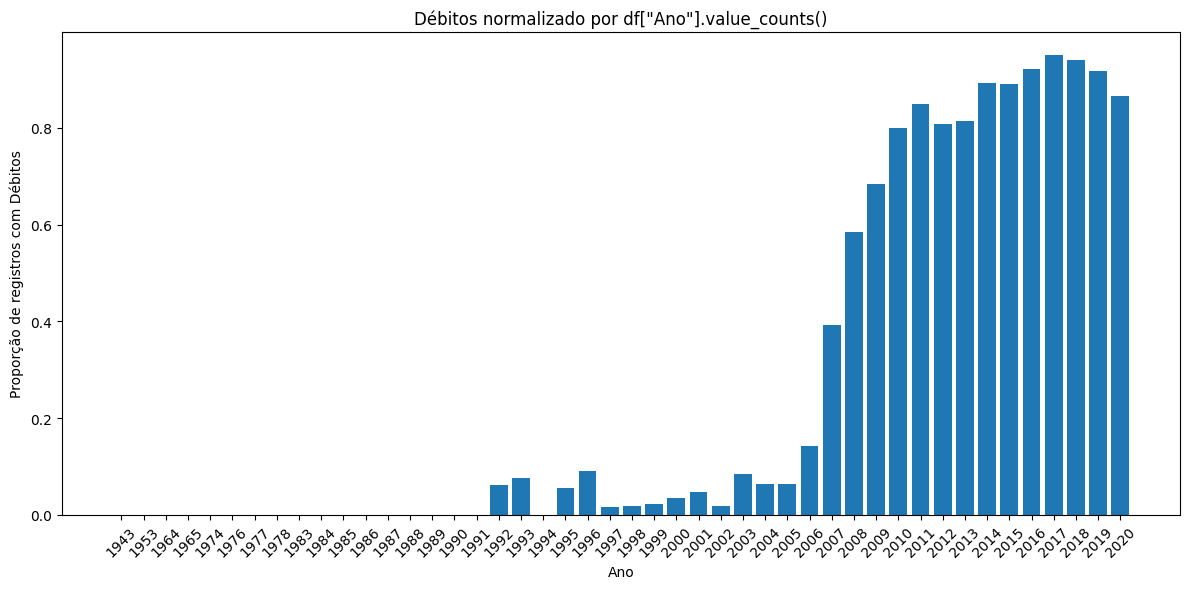

In [173]:
df["Ano"] = pd.to_numeric(df["Ano"], errors="coerce")

# Total de registros por ano
total_por_ano = df["Ano"].value_counts().sort_index()

# Quantidade de registros com Débitos válidos por ano
com_debito_por_ano = df.dropna(subset=["Ano", "Débitos"])["Ano"].value_counts().sort_index()

# Normalização pela contagem total de registros do ano
normalizado = (com_debito_por_ano / total_por_ano).fillna(0).sort_index()

graf = normalizado.reset_index()
graf.columns = ["Ano", "Proporcao_com_Debito"]

plt.figure(figsize=(12, 6))
plt.bar(graf["Ano"].astype(int).astype(str), graf["Proporcao_com_Debito"])
plt.xlabel("Ano")
plt.ylabel("Proporção de registros com Débitos")
plt.title('Débitos normalizado por df["Ano"].value_counts()')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [174]:
df['Débitos'] = df['Débitos'].fillna(0)
df['Débitos'].isna().sum()

0

### Coluna Fabricante

In [175]:
df["Fabricante"].value_counts()

Fabricante
TOYOTA           1794
HYUNDAI          1496
MERCEDES-BENZ     939
FORD              507
BMW               483
HONDA             469
CHEVROLET         468
LEXUS             460
NISSAN            275
VOLKSWAGEN        250
SSANGYONG         215
OPEL              185
KIA               176
MITSUBISHI        136
SUBARU            127
AUDI              114
MAZDA              81
JEEP               61
DAEWOO             45
SUZUKI             44
DODGE              39
FIAT               39
PORSCHE            29
LAND ROVER         28
VAZ                27
MINI               22
RENAULT            21
JAGUAR             19
CHRYSLER           12
INFINITI           11
ACURA              10
SKODA               9
LINCOLN             9
CADILLAC            9
DAIHATSU            8
GMC                 8
GAZ                 7
VOLVO               7
BUICK               5
PEUGEOT             4
CITROEN             4
ISUZU               3
SCION               3
UAZ                 3
MOSKVICH            3

In [176]:
df["Fabricante"].isna().sum()

0

### Coluna Modelo

In [177]:
df["Modelo"].value_counts()

Modelo
Prius              507
Camry              474
Elantra            407
Santa FE           264
Sonata             251
                  ... 
E 350 w211           1
Sonata HYBRID        1
Prius V ALPINA       1
Sprinter 315CDI      1
240                  1
Name: count, Length: 1032, dtype: int64

In [178]:
df["Modelo"].isna().sum()

0

### Coluna Ano

In [179]:
df["Ano"].value_counts()

Ano
2012    994
2014    946
2013    943
2011    736
2010    713
2016    632
2015    608
2017    430
2008    322
2009    259
2018    234
2007    217
2004    172
2003    165
2002    158
2005    156
2006    147
2019    147
2000    119
1998    109
2001    105
1999     90
1997     61
1996     55
1995     54
1994     21
1992     16
2020     15
1993     13
1988      7
1991      7
1989      6
1990      5
1984      5
1983      3
1974      2
1953      2
1985      2
1986      2
1964      1
1977      1
1987      1
1943      1
1978      1
1965      1
1976      1
Name: count, dtype: int64

In [180]:
df["Ano"].isna().sum()

0

### Coluna Categoria

In [181]:
df["Categoria"].value_counts()

Categoria
Sedan             3826
SUV               2555
Hatchback         1314
Minivan            285
Cupê               261
Universal          156
Microonibus        127
Vagao de carga     115
Picape              23
Conversivel         17
Limousine            6
Name: count, dtype: int64

In [182]:
df["Categoria"].isna().sum()

0

### Coluna Couro

In [183]:
df["Couro"].value_counts()

Couro
Sim    6192
Nao    2493
Name: count, dtype: int64

In [184]:
df["Couro"].isna().sum()

0

### Coluna Combustivel

In [185]:
df["Combustivel"].value_counts()

Combustivel
Gasolina       1966
Hibrido        1710
GASOLINA       1184
Gasol.          975
gasolina        777
Diesel          721
DIESEL          436
Dies.           379
diesel          305
Gás Natural     232
Name: count, dtype: int64

In [186]:
def normalizar_texto(texto):
    if pd.isna(texto):
        return texto
    
    texto = str(texto).strip().lower()
    
    # remove acentos
    texto = ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )
    
    return texto

mapeamento = {
    "gasolina": "Gasolina",
    "gasol.": "Gasolina",
    "diesel": "Diesel",
    "dies.": "Diesel",
    "hibrido": "Híbrido",
    "gas natural": "Gás Natural",
    "GASOLINA": "Gasolina",
}

df["Combustivel"] = (
    df["Combustivel"]
    .apply(normalizar_texto)
    .map(mapeamento)
    .fillna(df["Combustivel"])
)

In [187]:
df["Combustivel"].value_counts()

Combustivel
Gasolina       4902
Diesel         1841
Híbrido        1710
Gás Natural     232
Name: count, dtype: int64

In [188]:
df["Combustivel"].isna().sum()

0

### Coluna Volume_motor

In [189]:
df["Volume_motor"].value_counts()

Volume_motor
2            1556
2.5          1106
1.8           831
1.6           670
1.5           601
             ... 
2.1 Turbo       1
0.5             1
5.9             1
3.7 Turbo       1
6.4             1
Name: count, Length: 96, dtype: int64

In [190]:
df["Volume_motor"] = (
    df["Volume_motor"]
    .astype(str)
    .str.strip()
    .str.replace(",", ".", regex=False)
    .str.extract(r"(\d+(?:\.\d+)?)")[0]
)

df["Volume_motor"] = pd.to_numeric(df["Volume_motor"], errors="coerce")

In [191]:
df["Volume_motor"].value_counts()

Volume_motor
2.0    1751
2.5    1144
1.8     917
1.6     719
1.5     634
3.5     564
3.0     504
2.4     468
1.3     263
1.4     224
2.2     197
4.6     174
3.3     105
1.7      95
2.7      89
3.2      77
2.3      62
3.6      59
4.4      58
4.7      57
1.2      57
1.0      55
4.0      46
3.7      35
1.9      35
5.0      34
2.8      34
5.5      32
5.7      24
4.8      20
3.8      19
2.9      13
6.2      12
0.7      12
0.4      11
4.2      10
4.5       7
5.3       6
0.6       6
2.1       5
0.8       5
0.0       5
0.2       5
3.4       4
6.3       4
2.6       4
5.4       4
1.1       3
4.3       3
5.6       2
6.0       2
0.3       2
5.9       1
0.5       1
6.8       1
6.7       1
7.3       1
0.1       1
3.1       1
6.4       1
Name: count, dtype: int64

In [192]:
df["Volume_motor"].isna().sum()

0

### Coluna Km

In [193]:
df["Km"].value_counts()

Km
0 km         295
200000 km     71
150000 km     62
160000 km     57
100000 km     55
            ... 
132043 km      1
18900 km       1
152480 km      1
453000 km      1
119484 km      1
Name: count, Length: 3745, dtype: int64

In [194]:
df["Km"] = (
    df["Km"]
    .astype(str)
    .str.replace(" km", "", regex=False)
    .str.replace(".", "", regex=False)
    .str.strip()
)

df["Km"] = pd.to_numeric(df["Km"], errors="coerce")

In [195]:
df["Km"].value_counts()

Km
0.0         295
200000.0     71
150000.0     62
160000.0     57
100000.0     55
           ... 
132043.0      1
18900.0       1
152480.0      1
453000.0      1
119484.0      1
Name: count, Length: 3745, dtype: int64

In [196]:
df['Km'].isna().sum()

870

In [197]:
df.sort_values("Km")

,Débitos,Fabricante,Modelo,Ano,Categoria,Couro,Combustivel,Volume_motor,Km,Cilindros,...,Airbags,Preco,Numero_proprietarios,Data_ultima_lavagem,Adesivos_personalizados,Radio_AM_FM,Historico_troca_oleo,Codigo_concessionaria,Classificacao_Veiculo,Faixa_Preco
779,308.0,TOYOTA,Prius 2014,2014,Sedan,Sim,Híbrido,1.8,0.0,12,...,12,7997.0,3,2022-11-22,Não,AM,1,2192,Usado,Econômico
5081,0.0,BMW,318,2000,Sedan,Nao,Gás Natural,1.9,0.0,4,...,8,7840.0,5,2020-04-13,Não,FM,2,8206,Usado,Econômico
2920,1055.0,MERCEDES-BENZ,E 350,2013,Cupê,Sim,Diesel,3.5,0.0,6,...,12,627.0,3,2020-01-20,Não,AM/FM,10,7514,Usado,Econômico
5087,1018.0,AUDI,A6,2011,Sedan,Sim,Gasolina,3.0,0.0,6,...,12,1098.0,2,2021-01-31,Não,AM,3,4438,Usado,Econômico
7748,0.0,HONDA,FIT,2003,Hatchback,Nao,Gasolina,1.5,0.0,4,...,4,30.0,4,2022-05-28,Sim,AM,9,6697,Usado,Econômico
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8658,503.0,TOYOTA,Yaris,2012,Hatchback,Nao,Gasolina,1.5,NaN,4,...,8,12231.0,2,2022-06-26,Não,AM,4,6801,Usado,Econômico
8664,382.0,CHEVROLET,Volt,2017,Hatchback,Sim,Híbrido,1.5,NaN,4,...,0,26030.0,5,2020-02-03,Não,AM/FM,9,1086,Usado,Médio
8665,574.0,HONDA,Insight,2010,Hatchback,Sim,Híbrido,1.3,NaN,4,...,0,220.0,5,2022-06-27,Sim,FM,5,4031,Usado,Econômico
8667,1408.0,FORD,Transit,2007,Microonibus,Nao,Diesel,2.2,NaN,4,...,2,NaN,5,2020-09-12,Não,AM,6,7747,Usado,NaN


In [198]:
# Regras adicionais para tratar quilometragens improvaveis antes da modelagem.
# Mantive 2023 como referencia porque o notebook ja usa essa data em Data_ultima_lavagem.
ano_ref = 2023

df["Idade"] = (ano_ref - df["Ano"]).clip(lower=1)
df.loc[(df["Km"] >= 4_000_000.0) | (df["Km"] < 10_000), "Km"] = pd.NA

df["Km_por_ano"] = df["Km"] / df["Idade"]
km_str = df["Km"].round().astype("Int64").astype("string")

padrao_km_repetido = km_str.str.fullmatch(r"(\d)\1{4,}", na=False)
valores_km_sentinela = df["Km"].isin([
    11_111, 22_222, 33_333, 44_444, 55_555, 66_666, 77_777, 88_888, 99_999,
    111_111, 222_222, 333_333, 444_444, 555_555, 666_666, 777_777, 888_888, 999_999,
    1_111_111, 2_222_222, 123_456, 1_234_567, 101_010, 121_212
])

regra_km_suspeito = (
    (df["Km"] >= 1_000_000) |
    (df["Km_por_ano"] > 70_000) |
    ((df["Idade"] >= 2) & (df["Km_por_ano"] < 1_000)) |
    padrao_km_repetido |
    valores_km_sentinela
)

print("Km marcados como ausentes por regras adicionais:", int(regra_km_suspeito.sum()))
df.loc[regra_km_suspeito, "Km"] = pd.NA

df["Km_por_ano"] = df["Km"] / df["Idade"]

Km marcados como ausentes por regras adicionais: 139


In [199]:
df.sort_values("Km")

,Débitos,Fabricante,Modelo,Ano,Categoria,Couro,Combustivel,Volume_motor,Km,Cilindros,...,Numero_proprietarios,Data_ultima_lavagem,Adesivos_personalizados,Radio_AM_FM,Historico_troca_oleo,Codigo_concessionaria,Classificacao_Veiculo,Faixa_Preco,Idade,Km_por_ano
7392,0.0,TOYOTA,Aqua,2014,Sedan,Sim,Híbrido,1.5,10000.0,4,...,3,2020-09-10,Não,FM,10,4106,Usado,Econômico,9,1111.111111
3220,640.0,BMW,X1,2013,SUV,Sim,Gasolina,2.0,10000.0,4,...,4,2022-02-12,Sim,AM,0,9227,Usado,Médio,10,1000.000000
5906,779.0,TOYOTA,Camry,2013,Sedan,Nao,Gasolina,2.5,10000.0,6,...,3,2020-03-10,Sim,AM,2,8497,Usado,Médio,10,1000.000000
1183,1077.0,TOYOTA,CHR,2019,SUV,Sim,Gasolina,2.0,10003.0,4,...,5,2022-04-10,Sim,AM,9,5357,Semi-novo,Econômico,4,2500.750000
7309,1077.0,HYUNDAI,Santa FE,2019,SUV,Sim,Diesel,2.0,10120.0,4,...,1,2021-11-16,Não,FM,8,9031,Semi-novo,NaN,4,2530.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8673,0.0,OPEL,Astra,1994,Sedan,Nao,Gás Natural,1.6,NaN,4,...,1,2021-12-19,Sim,AM,10,2340,Usado,Econômico,29,NaN
8674,0.0,JAGUAR,E-pace p200,2020,SUV,Nao,Gasolina,2.0,NaN,4,...,4,2020-01-28,Não,AM,1,3870,Semi-novo,Muito Luxo,3,NaN
8676,0.0,VOLKSWAGEN,Passat,2004,Sedan,Sim,Gasolina,1.8,NaN,4,...,4,2021-11-02,Não,AM,8,2131,Usado,Econômico,19,NaN
8681,2004.0,MERCEDES-BENZ,240,1998,Sedan,Nao,Gasolina,2.4,NaN,6,...,5,2020-01-18,Não,FM,6,8892,Usado,Econômico,25,NaN


### Coluna Cilindros

In [200]:
df["Cilindros"].value_counts()

Cilindros
4     6428
6     1602
8      469
5       66
3       51
2       20
12      18
1       16
10       7
16       3
7        3
9        1
14       1
Name: count, dtype: int64

In [201]:
df['Cilindros'].isna().sum()

0

### Coluna Tipo_cambio

In [202]:
df["Tipo_cambio"].value_counts()

Tipo_cambio
Automatico    6046
Tiptronic     1405
Manual         865
Variator       369
Name: count, dtype: int64

In [203]:
df['Tipo_cambio'].isna().sum()

0

### Coluna Tração

In [204]:
df["Tração"].value_counts()

Tração
Dianteira    5744
4x4          1879
Traseira     1062
Name: count, dtype: int64

In [205]:
df['Tração'].isna().sum()

0

### Coluna Portas

In [206]:
df["Portas"].value_counts()

Portas
4-5    8243
2-3     387
>5       55
Name: count, dtype: int64

In [207]:
df['Portas'].isna().sum()

0

### Coluna Rodas

In [208]:
df["Rodas"].value_counts()

Rodas
21    310
19    299
6     297
20    296
15    295
24    291
3     291
29    285
25    284
23    279
4     277
13    276
32    272
31    271
2     271
11    270
1     269
27    269
18    267
12    266
5     261
10    259
9     259
8     259
17    258
22    256
30    255
14    253
7     252
16    249
26    247
28    242
Name: count, dtype: int64

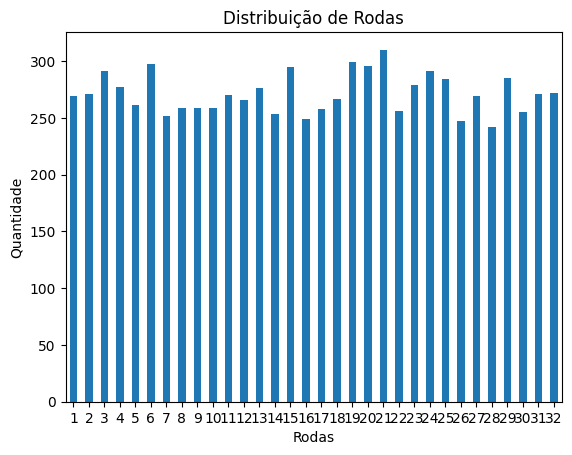

In [209]:
import matplotlib.pyplot as plt

df["Rodas"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Rodas")
plt.ylabel("Quantidade")
plt.title("Distribuição de Rodas")
plt.xticks(rotation=0)
plt.show()

In [210]:
df['Rodas'].isna().sum()

0

In [211]:
## Decidido por excluir a coluna "Rodas" devido a não conseguir entender o significado desse campo.
colunas_excluir = ["Rodas"]
df = df.drop(columns=colunas_excluir, errors="ignore")

### Coluna Cor

In [212]:
df["Cor"].value_counts()

Cor
Preto       2354
Branco      2037
Prata       1648
Cinza       1089
Azul         640
Red          311
Verde        142
Marrom        87
Vermelho      85
Bege          64
Azul ceu      59
Dourado       57
Amarelo       55
Laranja       26
Roxo          19
Rosa          12
Name: count, dtype: int64

In [213]:
import pandas as pd
import unicodedata

def normalizar_texto(texto):
    if pd.isna(texto):
        return texto
    
    texto = str(texto).strip().lower()
    texto = ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )
    return texto

mapeamento_cor = {
    "preto": "Preto",
    "branco": "Branco",
    "prata": "Prata",
    "cinza": "Cinza",
    "azul": "Azul",
    "azul ceu": "Azul",
    "red": "Vermelho",
    "vermelho": "Vermelho",
    "verde": "Verde",
    "marrom": "Marrom",
    "bege": "Bege",
    "amarelo": "Amarelo",
    "dourado": "Dourado",
    "laranja": "Laranja",
    "roxo": "Roxo",
    "rosa": "Rosa"
}

df["Cor"] = (
    df["Cor"]
    .apply(normalizar_texto)
    .map(mapeamento_cor)
    .fillna(df["Cor"])
)

In [214]:
df["Cor"].value_counts()

Cor
Preto       2354
Branco      2037
Prata       1648
Cinza       1089
Azul         699
Vermelho     396
Verde        142
Marrom        87
Bege          64
Dourado       57
Amarelo       55
Laranja       26
Roxo          19
Rosa          12
Name: count, dtype: int64

In [215]:
df['Cor'].isna().sum()

0

### Coluna Airbags

In [216]:
df["Airbags"].value_counts()

Airbags
12    2673
4     2418
0     1071
8      733
6      620
2      521
10     395
5       47
16      45
7       40
1       38
9       27
3       23
11      20
14      10
15       4
Name: count, dtype: int64

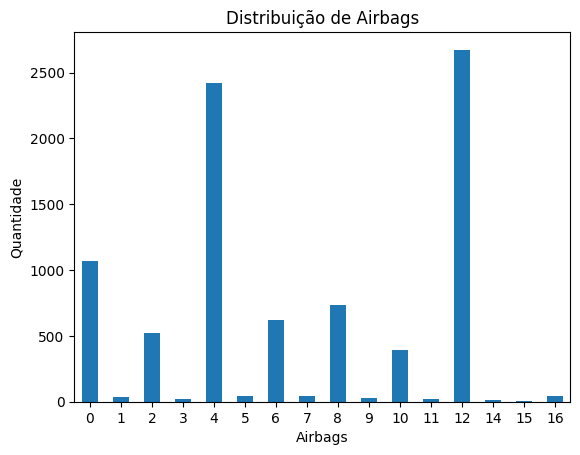

In [217]:
df["Airbags"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Airbags")
plt.ylabel("Quantidade")
plt.title("Distribuição de Airbags")
plt.xticks(rotation=0)
plt.show()

In [218]:
df['Airbags'].isna().sum()

0

### Coluna Preco

In [219]:
df['Preco'].describe()

count      8261.000000
mean      17700.684421
std       26383.538613
min           1.000000
25%        4861.000000
50%       13172.000000
75%       22825.000000
max      886993.000000
Name: Preco, dtype: float64

In [220]:
df["Preco"] = pd.to_numeric(df["Preco"], errors="coerce")
df = df.sort_values("Preco", ascending=True)
df.head(8000)

,Débitos,Fabricante,Modelo,Ano,Categoria,Couro,Combustivel,Volume_motor,Km,Cilindros,...,Numero_proprietarios,Data_ultima_lavagem,Adesivos_personalizados,Radio_AM_FM,Historico_troca_oleo,Codigo_concessionaria,Classificacao_Veiculo,Faixa_Preco,Idade,Km_por_ano
7418,0.0,OPEL,Astra,1999,Sedan,Sim,Gasolina,1.6,122231.0,4,...,3,2022-03-01,Sim,FM,5,1816,Usado,Econômico,24,5092.958333
4524,810.0,VOLKSWAGEN,Jetta,2016,Sedan,Sim,Gasolina,1.8,41000.0,4,...,3,2022-07-29,Não,AM,6,3838,Usado,Econômico,7,5857.142857
5588,0.0,MERCEDES-BENZ,CLK 230,2004,Cupê,Sim,Gasolina,2.3,328000.0,4,...,5,2021-05-02,Sim,AM/FM,5,1003,Usado,Econômico,19,17263.157895
4701,1502.0,VOLKSWAGEN,Jetta,2014,Sedan,Sim,Gasolina,1.8,134400.0,4,...,5,2020-04-11,Não,AM/FM,10,7208,Usado,Econômico,9,14933.333333
715,0.0,NISSAN,X-Terra,2004,SUV,Nao,Gasolina,3.3,NaN,6,...,4,2020-12-03,Sim,AM/FM,5,9266,Usado,Econômico,19,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4537,0.0,BMW,X5,2013,SUV,Sim,Diesel,3.0,NaN,6,...,3,2022-09-07,Não,FM,6,3069,Usado,Luxo,10,NaN
3214,0.0,PORSCHE,Cayenne,2011,SUV,Sim,Gasolina,3.5,171000.0,6,...,3,2020-03-22,Não,AM/FM,7,4319,Usado,Luxo,12,14250.000000
7896,1053.0,MERCEDES-BENZ,ML 350,2014,SUV,Sim,Diesel,3.5,190000.0,6,...,4,2020-07-02,Não,AM/FM,0,7069,Usado,Luxo,9,21111.111111
5608,1079.0,HONDA,Civic,2018,Sedan,Sim,Gasolina,2.0,26134.0,4,...,2,2022-01-07,Sim,AM/FM,3,7158,Semi-novo,Luxo,5,5226.800000


In [221]:
Q1 = df["Preco"].quantile(0.25)
Q3 = df["Preco"].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers_preco = df[(df["Preco"] < limite_inferior) | (df["Preco"] > limite_superior)]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Limite inferior:", limite_inferior)
print("Limite superior:", limite_superior)


Q1: 4861.0
Q3: 22825.0
IQR: 17964.0
Limite inferior: -22085.0
Limite superior: 49771.0


In [222]:
outliers_preco.head(100)

,Débitos,Fabricante,Modelo,Ano,Categoria,Couro,Combustivel,Volume_motor,Km,Cilindros,...,Numero_proprietarios,Data_ultima_lavagem,Adesivos_personalizados,Radio_AM_FM,Historico_troca_oleo,Codigo_concessionaria,Classificacao_Veiculo,Faixa_Preco,Idade,Km_por_ano
8084,765.0,HYUNDAI,Santa FE,2015,SUV,Sim,Diesel,2.0,93555.0,4,...,3,2020-01-11,Não,AM/FM,6,1059,Usado,Médio,8,11694.375000
427,765.0,HYUNDAI,Santa FE,2015,SUV,Sim,Diesel,2.0,93555.0,4,...,2,2021-02-26,Não,FM,6,8004,Usado,Médio,8,11694.375000
2066,891.0,HYUNDAI,Santa FE,2016,SUV,Sim,Diesel,2.0,126465.0,4,...,4,2020-05-15,Não,AM/FM,4,4812,Usado,Médio,7,18066.428571
266,1077.0,HYUNDAI,Tucson,2019,SUV,Sim,Diesel,2.0,48000.0,4,...,5,2020-01-18,Não,FM,7,6728,Semi-novo,Médio,4,12000.000000
4973,891.0,HYUNDAI,Santa FE,2016,SUV,Sim,Diesel,2.0,126465.0,4,...,1,2021-01-30,Sim,FM,3,3670,Usado,Médio,7,18066.428571
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5013,1017.0,HYUNDAI,Sonata,2017,Sedan,Sim,Gasolina,2.0,37844.0,4,...,4,2022-08-13,Sim,FM,6,8255,Usado,Luxo,6,6307.333333
1818,0.0,MERCEDES-BENZ,Viano,2013,Minivan,Sim,Diesel,2.2,250000.0,4,...,5,2022-11-19,Não,FM,1,5973,Usado,Luxo,10,25000.000000
4493,1058.0,LEXUS,RX 450,2012,SUV,Sim,Híbrido,3.5,65000.0,6,...,4,2020-03-26,Não,AM/FM,3,2405,Usado,Luxo,11,5909.090909
3746,1327.0,TOYOTA,Camry,2018,Sedan,Sim,Gasolina,2.5,NaN,6,...,5,2021-04-23,Sim,AM,7,6060,Semi-novo,Luxo,5,NaN


In [223]:
df = df[df["Preco"].notna()].copy()
df.head()

,Débitos,Fabricante,Modelo,Ano,Categoria,Couro,Combustivel,Volume_motor,Km,Cilindros,...,Numero_proprietarios,Data_ultima_lavagem,Adesivos_personalizados,Radio_AM_FM,Historico_troca_oleo,Codigo_concessionaria,Classificacao_Veiculo,Faixa_Preco,Idade,Km_por_ano
7418,0.0,OPEL,Astra,1999,Sedan,Sim,Gasolina,1.6,122231.0,4,...,3,2022-03-01,Sim,FM,5,1816,Usado,Econômico,24,5092.958333
4524,810.0,VOLKSWAGEN,Jetta,2016,Sedan,Sim,Gasolina,1.8,41000.0,4,...,3,2022-07-29,Não,AM,6,3838,Usado,Econômico,7,5857.142857
5588,0.0,MERCEDES-BENZ,CLK 230,2004,Cupê,Sim,Gasolina,2.3,328000.0,4,...,5,2021-05-02,Sim,AM/FM,5,1003,Usado,Econômico,19,17263.157895
4701,1502.0,VOLKSWAGEN,Jetta,2014,Sedan,Sim,Gasolina,1.8,134400.0,4,...,5,2020-04-11,Não,AM/FM,10,7208,Usado,Econômico,9,14933.333333
715,0.0,NISSAN,X-Terra,2004,SUV,Nao,Gasolina,3.3,NaN,6,...,4,2020-12-03,Sim,AM/FM,5,9266,Usado,Econômico,19,NaN


### Coluna Numero_proprietarios

In [224]:
df["Numero_proprietarios"].value_counts()

Numero_proprietarios
2    1711
5    1653
1    1638
3    1635
4    1624
Name: count, dtype: int64

In [225]:
df['Numero_proprietarios'].isna().sum()

0

### Coluna Data_ultima_lavagem

In [226]:
df["Data_ultima_lavagem"].value_counts()

Data_ultima_lavagem
2020-11-05    19
2021-04-08    18
2020-05-23    17
2020-07-26    17
2020-04-06    16
              ..
2021-08-02     2
2021-02-21     2
2022-05-09     2
2020-02-12     1
2020-08-15     1
Name: count, Length: 1096, dtype: int64

In [227]:
df["Data_ultima_lavagem"].astype(str).value_counts().head(30)

Data_ultima_lavagem
2020-11-05    19
2021-04-08    18
2020-05-23    17
2020-07-26    17
2020-04-06    16
2021-02-03    16
2021-04-03    16
2020-11-20    16
2022-03-10    15
2022-06-28    15
2022-02-01    15
2021-09-02    15
2020-03-09    15
2021-07-06    15
2022-05-17    14
2021-10-23    14
2021-12-08    14
2022-06-11    14
2022-08-10    14
2020-02-16    14
2020-10-22    14
2020-01-04    14
2021-01-22    14
2022-09-07    14
2022-11-20    14
2020-07-25    14
2020-06-17    14
2020-03-30    14
2022-08-17    14
2022-06-22    14
Name: count, dtype: int64

In [228]:
df["Data_ultima_lavagem"] = pd.to_datetime(
    df["Data_ultima_lavagem"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

In [229]:
# definir a data de referência
data_ref = pd.Timestamp("2023-01-01")

# calcular quantos dias se passaram
df["Dias_desde_ultima_lavagem"] = (data_ref - df["Data_ultima_lavagem"]).dt.days

df[["Data_ultima_lavagem", "Dias_desde_ultima_lavagem"]].head()

,Data_ultima_lavagem,Dias_desde_ultima_lavagem
7418,2022-03-01,306
4524,2022-07-29,156
5588,2021-05-02,609
4701,2020-04-11,995
715,2020-12-03,759


In [230]:
df['Data_ultima_lavagem'].isna().sum()

0

### Coluna Adesivos_personalizados

In [231]:
df["Adesivos_personalizados"].value_counts()

Adesivos_personalizados
Sim    4195
Não    4066
Name: count, dtype: int64

In [232]:
df['Adesivos_personalizados'].isna().sum()

0

### Coluna Radio_AM_FM

In [233]:
df["Radio_AM_FM"].value_counts()

Radio_AM_FM
FM       2809
AM/FM    2794
AM       2658
Name: count, dtype: int64

In [234]:
df['Radio_AM_FM'].isna().sum()

0

### Coluna Historico_troca_oleo

In [235]:
df["Historico_troca_oleo"].value_counts()

Historico_troca_oleo
9     800
8     769
6     764
4     764
0     755
1     754
10    737
5     732
7     732
3     732
2     722
Name: count, dtype: int64

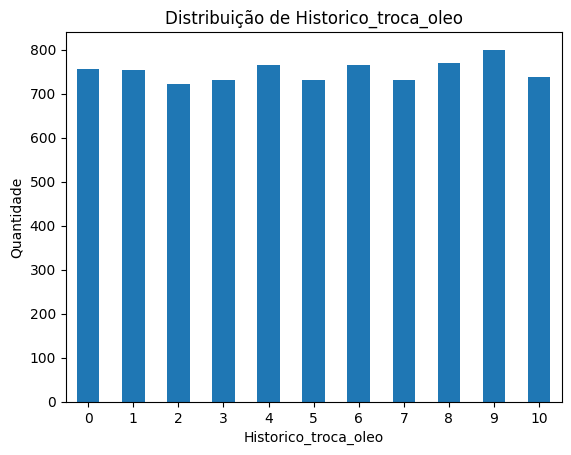

In [236]:
df["Historico_troca_oleo"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Historico_troca_oleo")
plt.ylabel("Quantidade")
plt.title("Distribuição de Historico_troca_oleo")
plt.xticks(rotation=0)
plt.show()

In [237]:
df['Historico_troca_oleo'].isna().sum()

0

### Coluna Codigo_concessionaria

In [238]:
df["Codigo_concessionaria"].value_counts()

Codigo_concessionaria
6890    7
7213    6
2423    6
7539    6
7544    6
       ..
2547    1
4126    1
1743    1
7302    1
9941    1
Name: count, Length: 5399, dtype: int64

In [239]:
colunas_excluir = ["Codigo_concessionaria"]
df = df.drop(columns=colunas_excluir, errors="ignore")

### Coluna Classificacao_Veiculo

In [240]:
df["Classificacao_Veiculo"].value_counts()

Classificacao_Veiculo
Usado        7889
Semi-novo     372
Name: count, dtype: int64

In [241]:
colunas_excluir = ["Classificacao_Veiculo"]
df = df.drop(columns=colunas_excluir, errors="ignore")

### Coluna Faixa_Preco

In [242]:
df["Faixa_Preco"].value_counts()

Faixa_Preco
Econômico     5745
Médio         2107
Luxo           352
Muito Luxo      57
Name: count, dtype: int64

In [243]:
colunas_excluir = ["Faixa_Preco"]
df = df.drop(columns=colunas_excluir, errors="ignore")

### Exportar para excel todos os possíveis valores das colunas

In [244]:
import pandas as pd

lista = []

for col in df.columns:
    vc = df[col].value_counts(dropna=False).reset_index()
    vc.columns = ["valor", "quantidade"]
    vc.insert(0, "coluna", col)
    lista.append(vc)

resultado = pd.concat(lista, ignore_index=True)
resultado.to_excel("value_counts_todas_colunas.xlsx", index=False)

# Predição de valores ausentes na coluna km

In [245]:
# Nao usar Preco aqui: se o objetivo final for prever Preco, isso causaria vazamento de informacao.
features_km = [
    'Débitos',
    'Fabricante',
    #'Modelo',
    #'Ano',
    'Idade',
    'Categoria',
    'Couro',
    'Combustivel',
    'Volume_motor',
    'Cilindros',
    'Tipo_cambio',
    'Tração',
    'Portas',
    #'Cor',
    #'Airbags',
    'Numero_proprietarios',
    'Dias_desde_ultima_lavagem',
    #'Adesivos_personalizados',
    #'Radio_AM_FM',
    'Historico_troca_oleo'
]

In [246]:
# =========================================================
# 1. Dados
# =========================================================
train_km = df[df["Km"].notna()].copy()

X = train_km[features_km]
y = train_km["Km"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

cat_km = X_train.select_dtypes(include="object").columns.tolist()
num_km = X_train.select_dtypes(exclude="object").columns.tolist()

def criar_one_hot_km():
    try:
        return OneHotEncoder(handle_unknown="ignore", min_frequency=10)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore")

prep_km = ColumnTransformer([
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", criar_one_hot_km())
    ]), cat_km),
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ]), num_km)
])

In [247]:
print(cat_km)

['Fabricante', 'Categoria', 'Couro', 'Combustivel', 'Tipo_cambio', 'Tração', 'Portas']


In [248]:
print(num_km)

['Débitos', 'Idade', 'Volume_motor', 'Cilindros', 'Numero_proprietarios', 'Dias_desde_ultima_lavagem', 'Historico_troca_oleo']


In [249]:
# =========================================================
# 2. Modelos + grids
# =========================================================
def regressao_log_km(modelo):
    return TransformedTargetRegressor(
        regressor=Pipeline([
            ("prep", prep_km),
            ("model", modelo)
        ]),
        func=np.log1p,
        inverse_func=np.expm1
    )

modelos = {
    "Ridge_log": {
        "pipeline": regressao_log_km(Ridge()),
        "params": {
            "regressor__model__alpha": [0.1, 1.0, 10.0, 100.0]
        }
    },

    "RandomForest_log": {
        "pipeline": regressao_log_km(RandomForestRegressor(random_state=42)),
        "params": {
            "regressor__model__n_estimators": [100, 200, 300, 500],
            "regressor__model__max_depth": [None, 10, 20, 30, 40],
            "regressor__model__min_samples_split": [2, 5, 10],
            "regressor__model__min_samples_leaf": [1, 2]
        }
    },

    "GradientBoosting_log": {
        "pipeline": regressao_log_km(GradientBoostingRegressor(random_state=42)),
        "params": {
            "regressor__model__n_estimators": [100, 200, 300, 500],
            "regressor__model__learning_rate": [0.05, 0.1, 0.01],
            "regressor__model__max_depth": [2, 3, 4, 5, 10]
        }
    },

    "ExtraTrees_log": {
        "pipeline": regressao_log_km(ExtraTreesRegressor(random_state=42)),
        "params": {
            "regressor__model__n_estimators": [100, 200, 300, 500],
            "regressor__model__max_depth": [None, 10, 20, 30, 40],
            "regressor__model__min_samples_split": [2, 5, 10],
            "regressor__model__min_samples_leaf": [1, 2]
        }
    },

    "LightGBM_L1_log": {
        "pipeline": regressao_log_km(LGBMRegressor(
            objective="regression_l1",
            metric="mae",
            random_state=42,
            n_jobs=1,
            verbosity=-1
        )),
        "params": {
            "regressor__model__n_estimators": [500, 700],
            "regressor__model__learning_rate": [0.025, 0.03],
            "regressor__model__num_leaves": [15, 31],
            "regressor__model__min_child_samples": [20, 30],
            "regressor__model__reg_lambda": [2.0, 5.0]
        }
    },

    "Blend_ExtraTrees_LightGBM_log": {
        "pipeline": regressao_log_km(VotingRegressor(
            estimators=[
                ("et", ExtraTreesRegressor(
                    n_estimators=400,
                    max_depth=20,
                    min_samples_leaf=1,
                    random_state=42,
                    n_jobs=1
                )),
                ("lgbm", LGBMRegressor(
                    objective="regression_l1",
                    metric="mae",
                    n_estimators=700,
                    learning_rate=0.025,
                    num_leaves=31,
                    min_child_samples=20,
                    reg_lambda=2.0,
                    random_state=42,
                    n_jobs=1,
                    verbosity=-1
                ))
            ],
            weights=[0.65, 0.35]
        )),
        "params": {}
    }
}

# =========================================================
# 3. Grid search em todos os modelos
# =========================================================
resultados_metricas = []
resultados_predicoes = {}
melhores_modelos = {}

for nome_modelo, cfg in modelos.items():
    print(f"\nTreinando {nome_modelo}...")

    grid = GridSearchCV(
        estimator=cfg["pipeline"],
        param_grid=cfg["params"],
        cv=5,
        scoring="neg_mean_absolute_error",
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    melhor_modelo = grid.best_estimator_
    y_pred = np.clip(melhor_modelo.predict(X_test), 0, None)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    r2 = r2_score(y_test, y_pred)

    resultados_metricas.append({
        "Modelo": nome_modelo,
        "Best_Params": str(grid.best_params_),
        "CV_MAE": -grid.best_score_,
        "MAE_teste": mae,
        "RMSE_teste": rmse,
        "R2_teste": r2
    })

    resultado_km = pd.DataFrame({
        "Km_real": y_test.values,
        "Km_predito": y_pred
    }, index=y_test.index)

    resultado_km["erro"] = resultado_km["Km_predito"] - resultado_km["Km_real"]
    resultado_km["erro_abs"] = resultado_km["erro"].abs()
    resultado_km = resultado_km.sort_values("Km_real", ascending=True)

    resultados_predicoes[nome_modelo] = resultado_km
    melhores_modelos[nome_modelo] = melhor_modelo

# =========================================================
# 4. Tabela de metricas
# =========================================================
df_metricas = pd.DataFrame(resultados_metricas).sort_values("MAE_teste")
print("\nResumo das metricas:")
print(df_metricas)


Treinando Ridge_log...

Treinando RandomForest_log...

Treinando GradientBoosting_log...

Treinando ExtraTrees_log...

Treinando LightGBM_L1_log...

Treinando Blend_ExtraTrees_LightGBM_log...

Resumo das metricas:
                          Modelo  \
5  Blend_ExtraTrees_LightGBM_log   
4                LightGBM_L1_log   
3                 ExtraTrees_log   
1               RandomForest_log   
2           GradientBoosting_log   
0                      Ridge_log   

                                         Best_Params        CV_MAE  \
5                                                 {}  45934.469735   
4  {'regressor__model__learning_rate': 0.025, 're...  46017.558929   
3  {'regressor__model__max_depth': 20, 'regressor...  46369.847201   
1  {'regressor__model__max_depth': 20, 'regressor...  46824.139858   
2  {'regressor__model__learning_rate': 0.05, 'reg...  47319.325593   
0                 {'regressor__model__alpha': 100.0}  55079.764610   

      MAE_teste    RMSE_teste  R2_teste  


Modelo: Ridge_log
      Km_real     Km_predito           erro       erro_abs
3624  10120.0   74069.450091   63949.450091   63949.450091
35    10200.0   58141.847381   47941.847381   47941.847381
4433  10610.0   61946.095084   51336.095084   51336.095084
5776  10670.0   84229.283751   73559.283751   73559.283751
3319  11000.0   67738.835296   56738.835296   56738.835296
4094  11000.0  119655.566173  108655.566173  108655.566173
41    11200.0   67321.651400   56121.651400   56121.651400
4985  11261.0   76501.058249   65240.058249   65240.058249
7094  11566.0   64884.781347   53318.781347   53318.781347
7113  11700.0  116802.316184  105102.316184  105102.316184
6791  12000.0   85941.542080   73941.542080   73941.542080
6918  12520.0   66263.043338   53743.043338   53743.043338
6990  12865.0   65244.864404   52379.864404   52379.864404
3160  13000.0   89664.390614   76664.390614   76664.390614
2621  13000.0  135348.100753  122348.100753  122348.100753
3609  13120.0  127001.011844  113881.

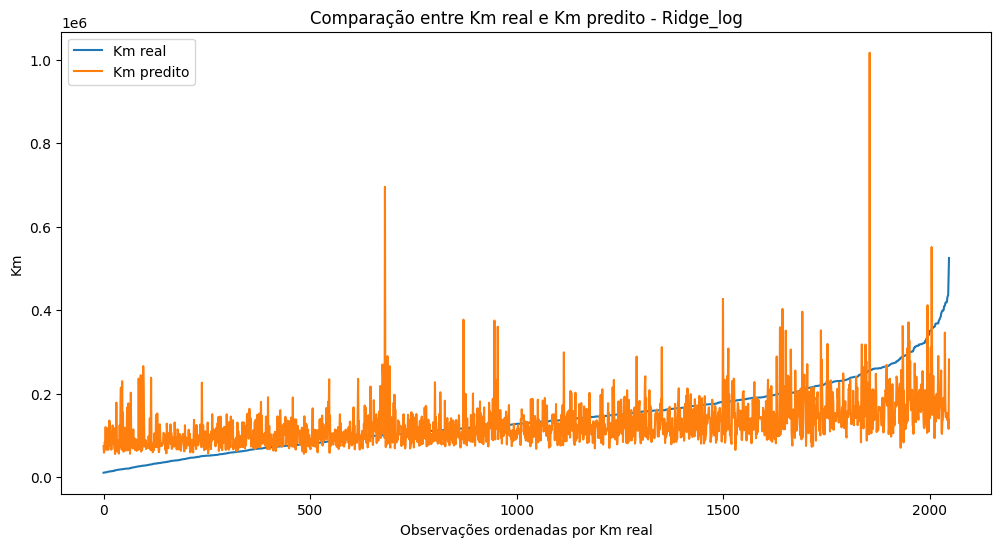


Modelo: RandomForest_log
      Km_real     Km_predito           erro       erro_abs
3624  10120.0   35685.702537   25565.702537   25565.702537
35    10200.0   25666.426301   15466.426301   15466.426301
4433  10610.0   24394.658702   13784.658702   13784.658702
5776  10670.0   24663.514285   13993.514285   13993.514285
3319  11000.0   65534.850537   54534.850537   54534.850537
4094  11000.0  112402.450623  101402.450623  101402.450623
41    11200.0   57408.731811   46208.731811   46208.731811
4985  11261.0   66600.960006   55339.960006   55339.960006
7094  11566.0   21275.832622    9709.832622    9709.832622
7113  11700.0  133991.186244  122291.186244  122291.186244
6791  12000.0  104720.454868   92720.454868   92720.454868
6918  12520.0   32007.186033   19487.186033   19487.186033
6990  12865.0   33309.602121   20444.602121   20444.602121
3160  13000.0   78712.571273   65712.571273   65712.571273
2621  13000.0   41752.415550   28752.415550   28752.415550
3609  13120.0  148372.604370  

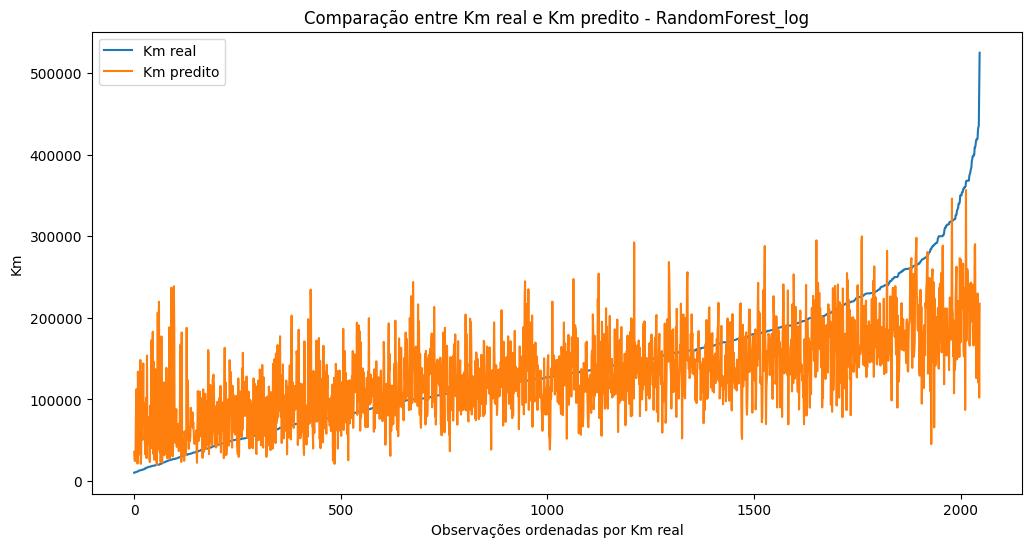


Modelo: GradientBoosting_log
      Km_real     Km_predito           erro       erro_abs
3624  10120.0   36575.518318   26455.518318   26455.518318
35    10200.0   29205.499068   19005.499068   19005.499068
4433  10610.0   24667.204993   14057.204993   14057.204993
5776  10670.0   22498.225416   11828.225416   11828.225416
3319  11000.0   67577.993197   56577.993197   56577.993197
4094  11000.0  109770.933484   98770.933484   98770.933484
41    11200.0   58688.200312   47488.200312   47488.200312
4985  11261.0   73605.735755   62344.735755   62344.735755
7094  11566.0   18413.434235    6847.434235    6847.434235
7113  11700.0  141165.137127  129465.137127  129465.137127
6791  12000.0   93547.903018   81547.903018   81547.903018
6918  12520.0   38009.368328   25489.368328   25489.368328
6990  12865.0   39494.269857   26629.269857   26629.269857
3160  13000.0   82509.567007   69509.567007   69509.567007
2621  13000.0   50155.684098   37155.684098   37155.684098
3609  13120.0  153383.5142

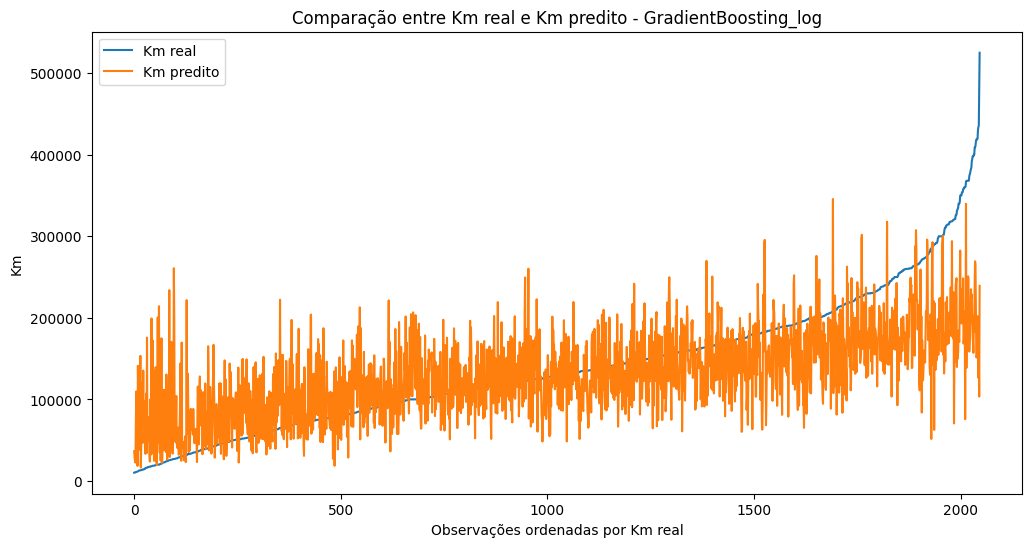


Modelo: ExtraTrees_log
      Km_real     Km_predito           erro       erro_abs
3624  10120.0   35010.505211   24890.505211   24890.505211
35    10200.0   36605.627600   26405.627600   26405.627600
4433  10610.0   24309.793079   13699.793079   13699.793079
5776  10670.0   20896.610751   10226.610751   10226.610751
3319  11000.0   74310.754795   63310.754795   63310.754795
4094  11000.0  120990.906432  109990.906432  109990.906432
41    11200.0   57720.646072   46520.646072   46520.646072
4985  11261.0   66308.910691   55047.910691   55047.910691
7094  11566.0   17357.108854    5791.108854    5791.108854
7113  11700.0  121150.179028  109450.179028  109450.179028
6791  12000.0   99703.179515   87703.179515   87703.179515
6918  12520.0   50591.201531   38071.201531   38071.201531
6990  12865.0   44405.487045   31540.487045   31540.487045
3160  13000.0   68972.866657   55972.866657   55972.866657
2621  13000.0   56052.552928   43052.552928   43052.552928
3609  13120.0  156575.674896  14

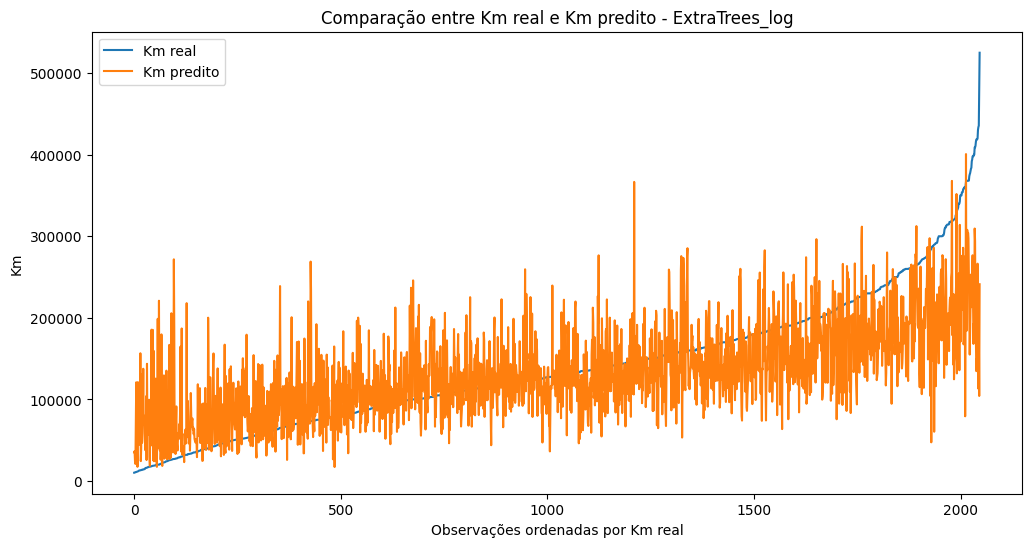


Modelo: LightGBM_L1_log
      Km_real     Km_predito           erro       erro_abs
3624  10120.0   33442.566345   23322.566345   23322.566345
35    10200.0   21587.128150   11387.128150   11387.128150
4433  10610.0   24343.245695   13733.245695   13733.245695
5776  10670.0   22770.004669   12100.004669   12100.004669
3319  11000.0   70131.822484   59131.822484   59131.822484
4094  11000.0  113247.704749  102247.704749  102247.704749
41    11200.0   59256.721011   48056.721011   48056.721011
4985  11261.0   70434.546628   59173.546628   59173.546628
7094  11566.0   23801.782498   12235.782498   12235.782498
7113  11700.0  129630.960769  117930.960769  117930.960769
6791  12000.0   95858.747833   83858.747833   83858.747833
6918  12520.0   30811.288292   18291.288292   18291.288292
6990  12865.0   46857.716941   33992.716941   33992.716941
3160  13000.0  102719.693464   89719.693464   89719.693464
2621  13000.0   42147.936578   29147.936578   29147.936578
3609  13120.0  152826.307416  1

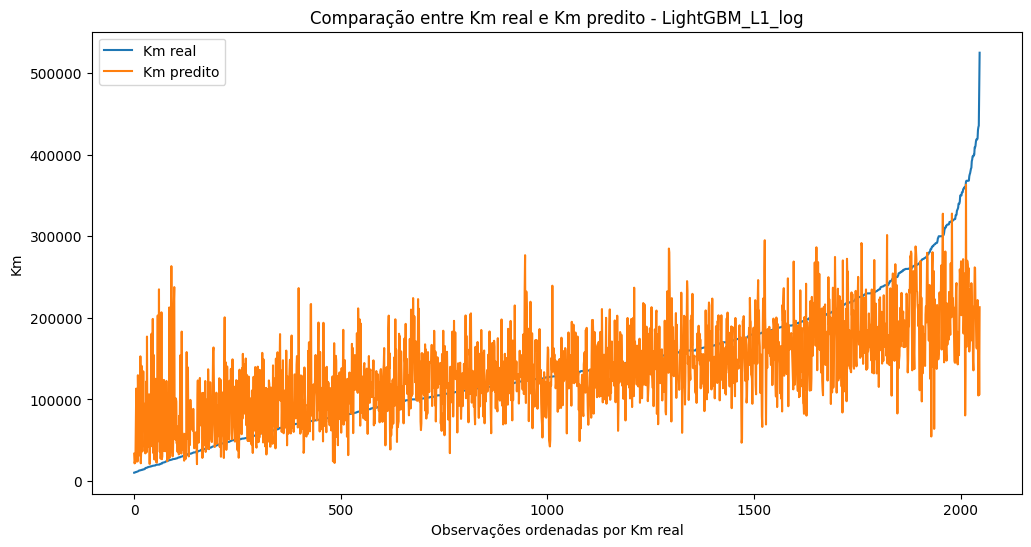


Modelo: Blend_ExtraTrees_LightGBM_log
      Km_real     Km_predito           erro       erro_abs
3624  10120.0   30385.085850   20265.085850   20265.085850
35    10200.0   42944.221491   32744.221491   32744.221491
4433  10610.0   24319.308115   13709.308115   13709.308115
5776  10670.0   20768.842145   10098.842145   10098.842145
3319  11000.0   71389.491141   60389.491141   60389.491141
4094  11000.0  111560.652204  100560.652204  100560.652204
41    11200.0   55459.417892   44259.417892   44259.417892
4985  11261.0   62298.408650   51037.408650   51037.408650
7094  11566.0   16801.364312    5235.364312    5235.364312
7113  11700.0  125374.771145  113674.771145  113674.771145
6791  12000.0  100579.278661   88579.278661   88579.278661
6918  12520.0   40636.273453   28116.273453   28116.273453
6990  12865.0   56638.959704   43773.959704   43773.959704
3160  13000.0   80748.485618   67748.485618   67748.485618
2621  13000.0   51013.092714   38013.092714   38013.092714
3609  13120.0  15

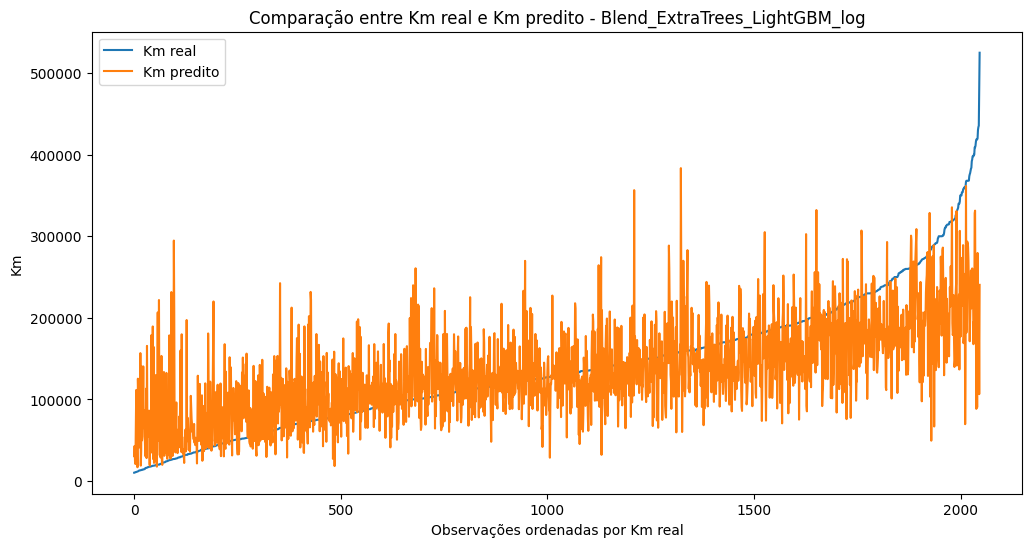

In [250]:
# =========================================================
# 5. Mostrar tabela e gráfico para cada modelo
# =========================================================
for nome_modelo, resultado_km in resultados_predicoes.items():
    print(f"\n{'='*60}")
    print(f"Modelo: {nome_modelo}")
    print(f"{'='*60}")
    print(resultado_km.head(20))

    resultado_plot = resultado_km.reset_index(drop=True)

    plt.figure(figsize=(12, 6))
    plt.plot(resultado_plot["Km_real"].values, label="Km real")
    plt.plot(resultado_plot["Km_predito"].values, label="Km predito")
    plt.xlabel("Observações ordenadas por Km real")
    plt.ylabel("Km")
    plt.title(f"Comparação entre Km real e Km predito - {nome_modelo}")
    plt.legend()
    plt.show()

In [251]:
# Treinar novamente, agora com todos os registros que tem Km conhecido,
# usando o melhor modelo escolhido pelo grid search.
km_faltante_antes_predicao = df["Km"].isna()
df["Km_imputado"] = km_faltante_antes_predicao.astype(int)

train_km_full = df[df["Km"].notna()].copy()
pred_km = df[km_faltante_antes_predicao].copy()

X_train_full = train_km_full[features_km]
y_train_full = train_km_full["Km"]

melhor_nome_km = df_metricas.iloc[0]["Modelo"]
model_km_final = clone(melhores_modelos[melhor_nome_km])
model_km_final.fit(X_train_full, y_train_full)

if len(pred_km) > 0:
    km_previsto = np.clip(model_km_final.predict(pred_km[features_km]), 0, None)
    df.loc[pred_km.index, "Km"] = km_previsto

# Atualizar a feature derivada depois da imputacao.
df["Km_por_ano"] = df["Km"] / df["Idade"]

print("Modelo usado para imputar Km:", melhor_nome_km)
print("Faltantes restantes em Km:", df["Km"].isna().sum())
print("Registros com Km imputado:", df["Km_imputado"].sum())

Modelo usado para imputar Km: Blend_ExtraTrees_LightGBM_log
Faltantes restantes em Km: 0
Registros com Km imputado: 1439


In [252]:
df.to_csv('database/test_tratado.csv', index=False)
#df.to_csv('database/train_mod_tratado.csv', index=False)